<a href="https://colab.research.google.com/github/Omar03-maker/Learning_Pyhton_Ml/blob/main/projet_final_data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Projet Final : Analyse des ventes de "Teranga Shop"

Bravo d'être arrivé au bout de cette semaine Data Science ! Ce projet va vous permettre de mobiliser tout ce que vous avez appris :
- **Jour 7** : Introduction à NumPy (tableaux, opérations vectorisées)
- **Jour 8** : NumPy avancé (reshape, masques booléens)
- **Jour 9** : Visualisation avec Matplotlib
- **Jour 10** : Manipulation de données avec Pandas
- **Jour 11** : Pandas avancé (groupby, valeurs manquantes)

## Votre mission
Vous êtes data analyst pour **Teranga Shop**, une boutique en ligne basée à Dakar. La direction souhaite un mini rapport sur les ventes de la semaine passée.

Dans chaque cellule de code, vous trouverez des commentaires `# À COMPLÉTER`. Remplacez-les par le code approprié en vous aidant des indices fournis.

Commençons par regarder le chiffre d'affaires (CA) de la semaine !

## Étape 1 : Le chiffre d'affaires quotidien (Jour 7 - NumPy)
Voici le chiffre d'affaires (en milliers de FCFA) réalisé par la boutique du lundi au dimanche.

**Instructions :**
1. Complétez `ca_total` en utilisant la méthode `.sum()` sur le tableau `ca_journalier`.
2. Complétez `ca_moyen` en utilisant la méthode `.mean()`.
3. Complétez `ca_max` en utilisant la méthode `.max()`.

In [1]:
import numpy as np

# CA (en milliers de FCFA) du lundi au dimanche
ca_journalier = np.array([320, 410, 280, 505, 460, 610, 390])
jours = np.array(["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"])

ca_total = ca_journalier.sum()

ca_moyen = ca_journalier.mean()

ca_max = ca_journalier.max()

print("CA total de la semaine :", ca_total)
print("CA moyen par jour :", ca_moyen)
print("Meilleur jour (CA max) :", ca_max)

CA total de la semaine : 2975
CA moyen par jour : 425.0
Meilleur jour (CA max) : 610


## Étape 2 : Repérer les bons jours (Jour 8 - Masques booléens)
La direction veut savoir quels jours ont dépassé le CA moyen de la semaine.

**Instructions :**
1. Créez `masque_bons_jours`, un masque booléen qui vaut `True` quand `ca_journalier` est supérieur à `ca_moyen`.
2. Utilisez ce masque pour extraire les valeurs de CA correspondantes dans `bons_jours`.
3. Utilisez le **même masque** pour extraire les noms des jours correspondants dans `noms_bons_jours` (indice : `jours[masque_bons_jours]`).

In [2]:
# Création masque booléen (True si ca_journalier > ca_moyen)
masque_bons_jours = ca_journalier > ca_moyen

# Application du masque à ca_journalier
bons_jours = ca_journalier[masque_bons_jours]

# Application du masque à jours pour connaître les noms des bons jours
noms_bons_jours = jours[masque_bons_jours]

print("Jours au-dessus de la moyenne :", noms_bons_jours)
print("CA de ces jours :", bons_jours)

Jours au-dessus de la moyenne : ['Jeudi' 'Vendredi' 'Samedi']
CA de ces jours : [505 460 610]


## Étape 3 : Le détail des ventes par produit (Jour 10 - Pandas)
Voici le détail des ventes par produit sous forme de dictionnaire. Nous allons le transformer en `DataFrame` Pandas.

**Instructions :**
1. Créez `df_ventes`, un `DataFrame` à partir du dictionnaire `donnees_ventes`.
2. Ajoutez une colonne `Chiffre_Affaires` égale à `Quantite * Prix_Unitaire` (opération vectorisée, comme avec NumPy !).

In [3]:
import pandas as pd

donnees_ventes = {
    "Produit": ["Écouteurs", "Clé USB", "Sac à dos", "Montre connectée", "Chargeur solaire", "Casquette"],
    "Region": ["Dakar", "Thiès", "Dakar", "Saint-Louis", "Dakar", "Thiès"],
    "Quantite": [12, 25, 8, 5, 15, 20],
    "Prix_Unitaire": [15, 5, 20, 45, 12, 7]
}

# Création le DataFrame à partir du dictionnaire donnees_ventes
df_ventes = pd.DataFrame(donnees_ventes)

# Ajout de la colonne Chiffre_Affaires = Quantite * Prix_Unitaire
df_ventes["Chiffre_Affaires"] = df_ventes["Quantite"] * df_ventes["Prix_Unitaire"]

df_ventes

,Produit,Region,Quantite,Prix_Unitaire,Chiffre_Affaires
0,Écouteurs,Dakar,12,15,180
1,Clé USB,Thiès,25,5,125
2,Sac à dos,Dakar,8,20,160
3,Montre connectée,Saint-Louis,5,45,225
4,Chargeur solaire,Dakar,15,12,180
5,Casquette,Thiès,20,7,140


## Étape 4 : Filtrer les produits les plus rentables (Jour 10 - Pandas)
La direction veut mettre en avant les produits qui rapportent le plus.

**Instructions :**
1. Complétez `produits_stars`, un DataFrame filtré ne contenant que les lignes où `Chiffre_Affaires` est supérieur ou égal à 150.

In [4]:
# Filtrage df_ventes pour ne garder que les lignes avec Chiffre_Affaires >= 150
produits_stars = df_ventes[df_ventes["Chiffre_Affaires"] >= 150]

produits_stars

,Produit,Region,Quantite,Prix_Unitaire,Chiffre_Affaires
0,Écouteurs,Dakar,12,15,180
2,Sac à dos,Dakar,8,20,160
3,Montre connectée,Saint-Louis,5,45,225
4,Chargeur solaire,Dakar,15,12,180


## Étape 5 : Le chiffre d'affaires par région (Jour 11 - GroupBy)
Combien chaque région a-t-elle rapporté au total ?

**Instructions :**
1. Complétez `ca_par_region` en utilisant `.groupby()` sur la colonne `Region`, puis `.sum()` sur la colonne `Chiffre_Affaires`.

In [5]:
# Regroupement df_ventes par Region et sommez la colonne Chiffre_Affaires
ca_par_region = df_ventes.groupby("Region")["Chiffre_Affaires"].sum()

ca_par_region

,Chiffre_Affaires
Region,
Dakar,520
Saint-Louis,225
Thiès,265


## Étape 6 : Satisfaction client et valeurs manquantes (Jour 11 - Pandas avancé)
Après chaque vente, les clients laissent une note de satisfaction sur 5. Malheureusement, certains clients n'ont pas répondu (`None`).

**Instructions :**
1. Complétez `note_moyenne`, la moyenne des notes disponibles (Pandas ignore automatiquement les `NaN` avec `.mean()`).
2. Complétez `df_satisfaction_rempli` en remplaçant les valeurs manquantes de la colonne `Note` par `note_moyenne` grâce à `.fillna()`.

In [6]:
df_satisfaction = pd.DataFrame({
    "Client": ["Aminata", "Moussa", "Fatou", "Ibrahima", "Khady"],
    "Note": [4.5, None, 3.0, None, 5.0]
})

# Calcul de la moyenne des notes disponibles
note_moyenne = df_satisfaction["Note"].mean()

# Remplacement des valeurs manquantes de la colonne Note par note_moyenne
df_satisfaction_rempli = df_satisfaction.copy()
df_satisfaction_rempli["Note"] = df_satisfaction_rempli["Note"].fillna(note_moyenne)

df_satisfaction_rempli

,Client,Note
0,Aminata,4.500000
1,Moussa,4.166667
2,Fatou,3.000000
3,Ibrahima,4.166667
4,Khady,5.000000


## Étape 7 : Visualisation (Jour 9 - Matplotlib)
Un bon rapport se termine toujours par des graphiques !

**Instructions :**
1. Complétez le premier graphique : une courbe (`plt.plot`) montrant l'évolution de `ca_journalier` en fonction de `jours`, avec un titre `"Évolution du CA - Teranga Shop"`.
2. Complétez le second graphique : un diagramme en barres (`plt.bar`) montrant `ca_par_region`, avec un titre `"CA par région"`.
   - Indice : pour un `groupby`, les noms des régions sont dans `ca_par_region.index` et les valeurs dans `ca_par_region.values`.

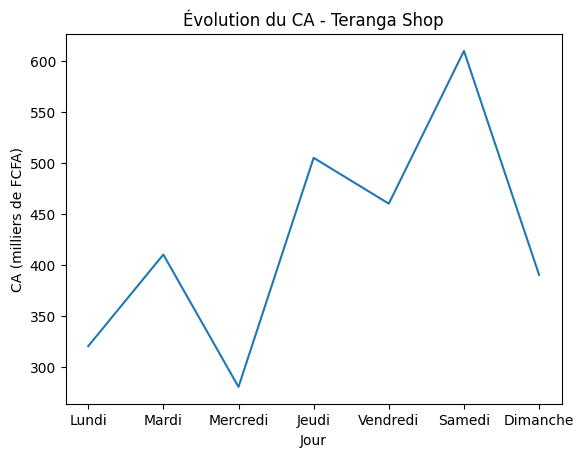

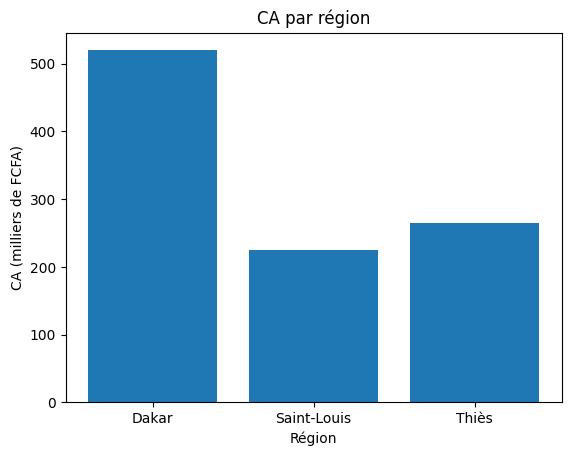

In [7]:
import matplotlib.pyplot as plt

# Graphique 1 : évolution du CA sur la semaine
plt.figure()
# Courbe ca_journalier en fonction de jours (plt.plot)
plt.plot(jours, ca_journalier)

plt.title("Évolution du CA - Teranga Shop")
plt.xlabel("Jour")
plt.ylabel("CA (milliers de FCFA)")
plt.show()

# Graphique 2 : CA par région
plt.figure()
# Diagramme en barres avec ca_par_region.index et ca_par_region.values
plt.bar(ca_par_region.index, ca_par_region.values)

plt.title("CA par région")
plt.xlabel("Région")
plt.ylabel("CA (milliers de FCFA)")
plt.show()

## Étape 8 : Validation de votre code
Exécutez cette cellule pour vérifier que tout ce que vous avez codé jusqu'ici est correct.

In [8]:
def tester_code():
    try:
        # Test Étape 1 : NumPy
        assert ca_total == ca_journalier.sum(), "ca_total est incorrect"
        assert round(ca_moyen, 2) == round(ca_journalier.mean(), 2), "ca_moyen est incorrect"
        assert ca_max == ca_journalier.max(), "ca_max est incorrect"

        # Test Étape 2 : Masques booléens
        assert masque_bons_jours is not None and masque_bons_jours.dtype == bool, "masque_bons_jours doit être un tableau de booléens"
        assert list(bons_jours) == list(ca_journalier[ca_journalier > ca_moyen]), "bons_jours est incorrect"
        assert list(noms_bons_jours) == list(jours[ca_journalier > ca_moyen]), "noms_bons_jours est incorrect"

        # Test Étape 3 : DataFrame
        assert isinstance(df_ventes, pd.DataFrame), "df_ventes doit être un DataFrame"
        assert "Chiffre_Affaires" in df_ventes.columns, "La colonne Chiffre_Affaires est manquante"
        assert df_ventes["Chiffre_Affaires"].iloc[0] == 12 * 15, "Le calcul de Chiffre_Affaires est incorrect"

        # Test Étape 4 : Filtrage
        assert isinstance(produits_stars, pd.DataFrame), "produits_stars doit être un DataFrame"
        assert (produits_stars["Chiffre_Affaires"] >= 150).all(), "produits_stars contient des lignes en dessous de 150"
        assert len(produits_stars) > 0, "produits_stars ne doit pas être vide"

        # Test Étape 5 : GroupBy
        assert round(ca_par_region["Dakar"], 2) == round(12*15 + 8*20 + 15*12, 2), "ca_par_region est incorrect"

        # Test Étape 6 : Valeurs manquantes
        assert round(note_moyenne, 2) == round(df_satisfaction["Note"].mean(), 2), "note_moyenne est incorrect"
        assert df_satisfaction_rempli["Note"].isna().sum() == 0, "Il reste des valeurs manquantes dans df_satisfaction_rempli"

        print("✅ BRAVO ! Toutes les étapes sont correctes. Votre rapport est prêt !")
        print("Vous pouvez maintenant exécuter la cellule ci-dessous pour générer le rapport final.")
    except AssertionError as e:
        print(f"❌ Oups, il y a une erreur : {e}")
        print("Corrigez votre code dans les cellules du haut, puis relancez ce test.")
    except Exception as e:
        print(f"❌ Une cellule précédente n'a pas encore été complétée ou contient une erreur : {e}")

tester_code()

✅ BRAVO ! Toutes les étapes sont correctes. Votre rapport est prêt !
Vous pouvez maintenant exécuter la cellule ci-dessous pour générer le rapport final.


## Étape 9 : Génération du rapport final
Exécutez cette dernière cellule pour afficher le résumé destiné à la direction de Teranga Shop !

In [10]:
def generer_rapport():
    print("=" * 45)
    print("   RAPPORT HEBDOMADAIRE - TERANGA SHOP")
    print("=" * 45)
    print(f"CA total de la semaine : {ca_total} milliers FCFA")
    print(f"CA moyen par jour      : {ca_moyen:.2f} milliers FCFA")
    print(f"Meilleur jour          : {ca_max} milliers FCFA")
    print(f"Jours au-dessus de la moyenne : {list(noms_bons_jours)}")
    print("-" * 45)
    print("Top produits (CA >= 150) :")
    print(produits_stars[["Produit", "Chiffre_Affaires"]].to_string(index=False))
    print("-" * 45)
    print("CA par région :")
    print(ca_par_region.to_string())
    print("-" * 45)
    print(f"Note de satisfaction moyenne : {note_moyenne:.2f} / 5")
    print("=" * 45)

generer_rapport()

   RAPPORT HEBDOMADAIRE - TERANGA SHOP
CA total de la semaine : 2975 milliers FCFA
CA moyen par jour      : 425.00 milliers FCFA
Meilleur jour          : 610 milliers FCFA
Jours au-dessus de la moyenne : [np.str_('Jeudi'), np.str_('Vendredi'), np.str_('Samedi')]
---------------------------------------------
Top produits (CA >= 150) :
         Produit  Chiffre_Affaires
       Écouteurs               180
       Sac à dos               160
Montre connectée               225
Chargeur solaire               180
---------------------------------------------
CA par région :
Region
Dakar          520
Saint-Louis    225
Thiès          265
---------------------------------------------
Note de satisfaction moyenne : 4.17 / 5
